Saving Middle Age.csv to Middle Age.csv
    Split     Model  Accuracy  Precision    Recall
0   80:20        RF  0.995086   0.995137  0.995086
1   80:20        DT  0.995086   0.995137  0.995086
2   80:20        ET  0.995086   0.995137  0.995086
3   80:20       SVM  0.974201   0.974589  0.974201
4   80:20       KNN  0.939803   0.941158  0.939803
5   80:20  AdaBoost  0.987715   0.987730  0.987715
6   80:20   Bagging  0.995086   0.995137  0.995086
7   80:20        LR  0.987715   0.987769  0.987715
8   80:20        NB  0.992629   0.992643  0.992629
9   80:20        GB  0.995086   0.995137  0.995086
10  70:30        RF  0.992629   0.992740  0.992629
11  70:30        DT  0.990172   0.990261  0.990172
12  70:30        ET  0.994267   0.994334  0.994267
13  70:30       SVM  0.967240   0.968134  0.967240
14  70:30       KNN  0.945127   0.946369  0.945127
15  70:30  AdaBoost  0.990991   0.991102  0.990991
16  70:30   Bagging  0.990172   0.990368  0.990172
17  70:30        LR  0.988534   0.988730  

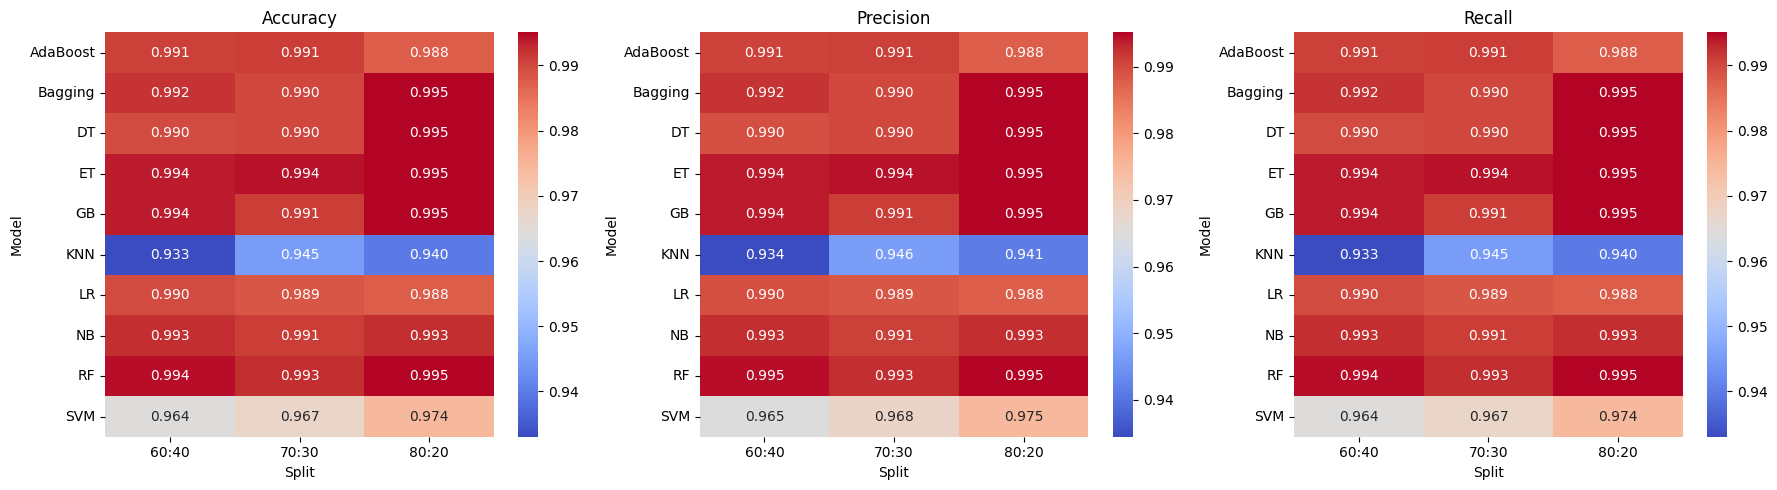

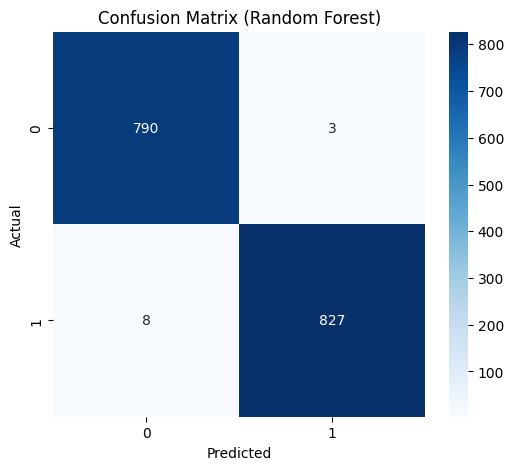

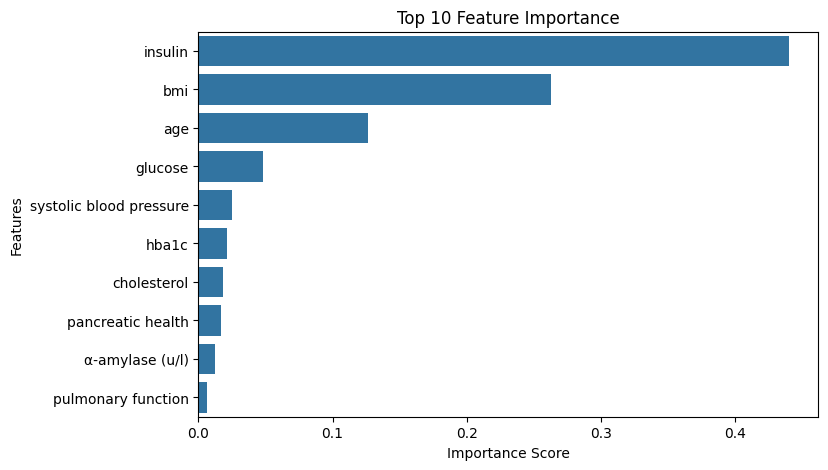

In [5]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

# ================================
# 2. UPLOAD DATASET
# ================================
from google.colab import files
uploaded = files.upload()

data = pd.read_csv(next(iter(uploaded)))

# ================================
# 3. CLEAN COLUMN NAMES
# ================================
data.columns = data.columns.str.strip().str.lower()

# Rename columns for simplicity
data = data.rename(columns={
    'age (years)': 'age',
    'fasting blood glucose (mg/dl)': 'glucose',
    'insulin levels (μu/ml)': 'insulin',
    'bmi (kg/m²)': 'bmi',
    'cholesterol levels (mg/dl)': 'cholesterol',
    'type of diabetes': 'target'
})

# ================================
# 4. DATA PREPROCESSING
# ================================
data = data.dropna()
data = data.drop_duplicates()

# Encode categorical variables
le = LabelEncoder()
categorical_cols = data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# ================================
# 5. FEATURE SCALING
# ================================
scaler = StandardScaler()

numerical_cols = ['age', 'glucose', 'insulin', 'bmi', 'hba1c',
                  'systolic blood pressure', 'cholesterol']

data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

# ================================
# 6. RANDOM OVERSAMPLING (FIXED)
# ================================
class_counts = data['target'].value_counts()

majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

majority = data[data['target'] == majority_class]
minority = data[data['target'] == minority_class]

minority_upsampled = resample(minority,
                             replace=True,
                             n_samples=len(majority),
                             random_state=42)

data_balanced = pd.concat([majority, minority_upsampled])

# ================================
# 7. FEATURES & TARGET
# ================================
X = data_balanced.drop('target', axis=1)
y = data_balanced['target']

# ================================
# 8. MODELS
# ================================
models = {
    "RF": RandomForestClassifier(),
    "DT": DecisionTreeClassifier(),
    "ET": ExtraTreesClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "LR": LogisticRegression(max_iter=1000),
    "NB": GaussianNB(),
    "GB": GradientBoostingClassifier()
}

# ================================
# 9. DATA SPLITS
# ================================
splits = {
    "80:20": 0.2,
    "70:30": 0.3,
    "60:40": 0.4
}

# ================================
# 10. TRAINING + EVALUATION
# ================================
results = []

for split_name, test_size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')

        results.append([split_name, name, acc, prec, rec])

# ================================
# 11. RESULTS TABLE
# ================================
results_df = pd.DataFrame(results, columns=[
    "Split", "Model", "Accuracy", "Precision", "Recall"
])

print(results_df)

# ================================
# 12. HEATMAPS
# ================================
pivot_acc = results_df.pivot(index="Model", columns="Split", values="Accuracy")
pivot_prec = results_df.pivot(index="Model", columns="Split", values="Precision")
pivot_rec = results_df.pivot(index="Model", columns="Split", values="Recall")

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Accuracy")

plt.subplot(1,3,2)
sns.heatmap(pivot_prec, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Precision")

plt.subplot(1,3,3)
sns.heatmap(pivot_rec, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Recall")

plt.tight_layout()
plt.show()

# ================================
# 13. CONFUSION MATRIX
# ================================
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ================================
# 14. FEATURE IMPORTANCE
# ================================
importances = best_model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_features = feat_df.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=top_features)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

